In diesem RF-Modell werden erstmal die Sensoren 5459 und 15449 entfernt, es wird mithilfe von einem Imputer jeder NA-Wert durch den Durchschnitt von Würzburg befüllt um eine möglichst große Datenmenge zu haben.
Mit der 10-fold-validation können wir nicht arbeiten, denn diese wirft alle Datenzeilen zusammen, vermischt sie und testet 10 mal an 10 % der Daten, dadurch ist ein spatial overfitting sehr wahrscheinlich. Deswegen nutzen wir den Leave-Location-Out-Ansatz welcher durch das Training von 6 Sensoren ein 6-Fold LLO ist.

**Erste Erkentnisse:**
- 46505 große Abweichungen (nur Daten im August), Mindestanzahl für Datenlieferungen (9094 raus, nur 2 Daten), Spatial Overfitting (zu viele Features)
- Von den MAIAC-Werten wurden 71 % durch Imputerwerte ersetzt, also für 71 % gibt es keine Werte

Mit NDVI:
Mittlerer R² Score:   -0.87
Mittlerer RMSE:       2.90 µg/m³
Mittlerer Bias:       1.00 µg/m³

Ohne NDVI:
Mittlerer R² Score:   -0.66
Mittlerer RMSE:       2.90 µg/m³
Mittlerer Bias:       0.59 µg/m³


Schritt 2: Führe Baseline-Kalibrierung der Hardware durch...
-> Systematischer Offset (3.42 µg/m³) angeglichen!
Starte optimierte LLO-Kreuzvalidierung...
Fold 1 (Test auf Sensor 10645): R² = -0.04 | RMSE = 1.76 µg/m³ | Bias =  1.46 µg/m³
Fold 2 (Test auf Sensor 13975): R² =  0.20 | RMSE = 1.95 µg/m³ | Bias =  1.35 µg/m³
Fold 3 (Test auf Sensor 19623): R² =  0.46 | RMSE = 1.81 µg/m³ | Bias = -0.96 µg/m³
Fold 4 (Test auf Sensor 25049): R² =  0.08 | RMSE = 3.15 µg/m³ | Bias = -1.70 µg/m³
Number of observations: 572

GESAMTERGEBNIS DES OPTIMIERTEN LLO-TESTS:
Mittlerer R² Score:   0.18
Mittlerer RMSE:       2.16 µg/m³
Mittlerer Bias:       0.04 µg/m³
--------------------------------------------------
FEATURE WICHTIGKEIT:
        icon_temp_2m:  30.7 %
icon_relative_humidity:  14.8 %
     icon_wind_speed:   9.4 %
 icon_wind_direction:   8.7 %
             IDW_car:   7.2 %
            ERA5_BLH:   6.3 %
             S5P_NO2:   5.4 %
            S5P_UVAI:   4.6 %
     icon_precip_12h:   4.3 %
 

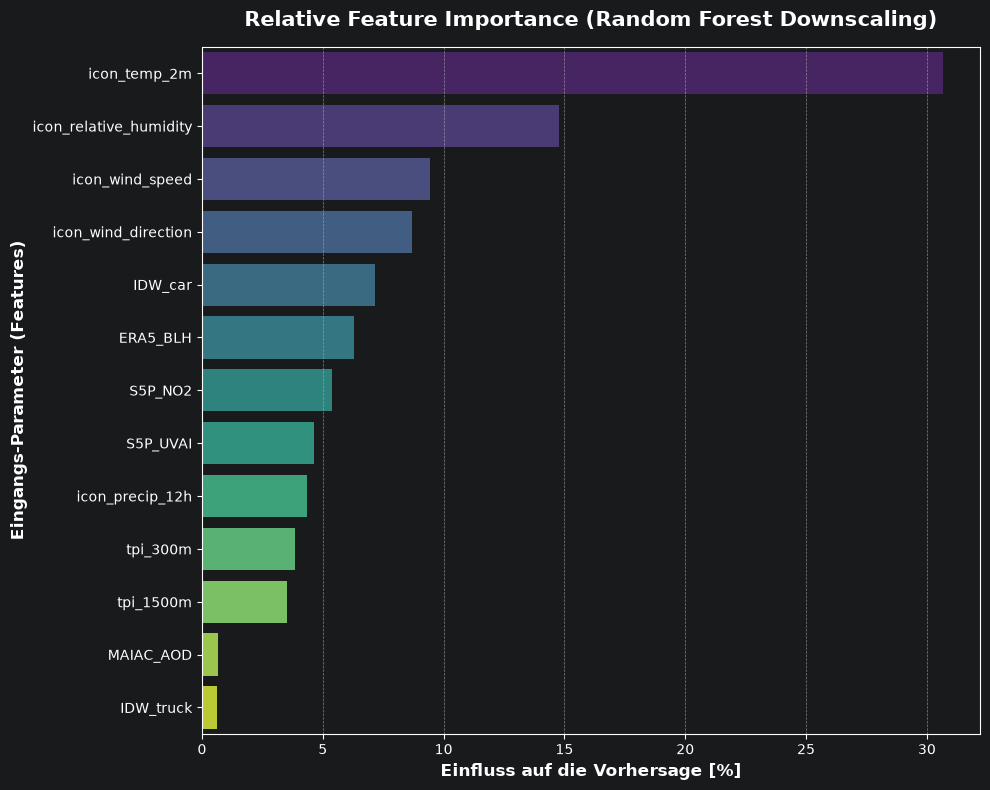

-> Feature Importance Plot erfolgreich gespeichert unter:
   C:\Users\AD\Desktop\Uni Würzburg\EAGLE\InnoLab\new_Output\Diagrams\Feature_Importance_RF_Imputer_Model.png


In [9]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# =========================================================
# 1. Daten laden & bereinigen
# =========================================================
file_path = r"C:\Users\AD\Desktop\Uni Würzburg\EAGLE\InnoLab\new_Output\IDW_hoch2\Exp2_Features_RH_PM25_NDVI_TPI_S5P_ERA5_MAIAC_Verkehr_Wetter.csv"
df = pd.read_csv(file_path, sep=";", decimal=",")

df['station_id'] = df['station_id'].astype(str).str.strip()

# KAPUTTE / VERZERRENDE SENSOREN ENTFERNEN (inklusive dem -18.44 Ausreißer 46505!)
bad_sensors = ['5456', '15449', '46505', '9094']
df = df[~df['station_id'].isin(bad_sensors)].copy()

df = df.dropna(subset=['PM25_Target'])

# Qualitäts-Filter: Mindestens 20 Tage
sensor_counts = df['station_id'].value_counts()
valid_sensors = sensor_counts[sensor_counts >= 20].index
df = df[df['station_id'].isin(valid_sensors)].copy()

# =========================================================
# 2. Imputation der Satelliten-Lücken
# =========================================================
features = [
    #'prox_kumulativ_car', 'prox_kumulativ_truck',
    'IDW_car', 'IDW_truck',
    'icon_temp_2m', 'icon_wind_speed', 'icon_wind_direction',
    'icon_precip_12h', 'icon_relative_humidity',
    'MAIAC_AOD', 'S5P_NO2', 'S5P_UVAI', 'ERA5_BLH',
    'tpi_300m', 'tpi_1500m'
]

imputer = SimpleImputer(strategy='median')
df[features] = imputer.fit_transform(df[features])

# =========================================================
# 3. Hardware-Kalibrierung: Low-Cost an Kopfklinik anpassen
# =========================================================
print("\nSchritt 2: Führe Baseline-Kalibrierung der Hardware durch...")
mean_kopfklinik = df[df['station_id'] == "1"]['PM25_Target'].mean()
mean_lowcost = df[df['station_id'] != "1"]['PM25_Target'].mean()

offset = mean_kopfklinik - mean_lowcost
df.loc[df['station_id'] != "1", 'PM25_Target'] += offset
print(f"-> Systematischer Offset ({offset:.2f} µg/m³) angeglichen!")


# =========================================================
# 3. Leave-Location-Out (LLO) Validierung
# =========================================================
print("Starte optimierte LLO-Kreuzvalidierung...")

ANCHOR_ID = "1"
test_stations = [s for s in df['station_id'].unique() if s != ANCHOR_ID]

fold_results = []
# NEU: Regularisierung! max_depth begrenzt das Auswendiglernen, min_samples_leaf zwingt zu allgemeineren Regeln
rf = RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=4, random_state=42, n_jobs=-1)

# Um die Wichtigkeit der Features am Ende zu mitteln
feature_importances_list = []

for fold, test_sensor in enumerate(test_stations, 1):
    test_mask = df['station_id'] == test_sensor
    df_test = df[test_mask]
    df_train = df[~test_mask]

    X_train = df_train[features]
    y_train = df_train['PM25_Target']
    X_test = df_test[features]
    y_test = df_test['PM25_Target']

    # Gewichtung leicht auf 2.0 reduziert, um den Bias abzuflachen
    sample_weights = np.where(df_train['station_id'] == ANCHOR_ID, 1.0, 1.0)

    rf.fit(X_train, y_train, sample_weight=sample_weights)

    y_pred = rf.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    bias = np.mean(y_pred - y_test)

    fold_results.append({'Sensor': test_sensor, 'R2': r2, 'RMSE': rmse, 'Bias': bias})
    feature_importances_list.append(rf.feature_importances_)

    print(f"Fold {fold} (Test auf Sensor {test_sensor}): R² = {r2:5.2f} | RMSE = {rmse:4.2f} µg/m³ | Bias = {bias:5.2f} µg/m³")

# =========================================================
# 4. Endauswertung & Feature Importance
# =========================================================
print("Number of observations:", len(df))

print("\n" + "="*50)
print("GESAMTERGEBNIS DES OPTIMIERTEN LLO-TESTS:")
print("="*50)
results_df = pd.DataFrame(fold_results)
print(f"Mittlerer R² Score:   {results_df['R2'].mean():.2f}")
print(f"Mittlerer RMSE:       {results_df['RMSE'].mean():.2f} µg/m³")
print(f"Mittlerer Bias:       {results_df['Bias'].mean():.2f} µg/m³")
print("-" * 50)

# Feature Importance Ausgabe
mean_importances = np.mean(feature_importances_list, axis=0)
importance_df = pd.DataFrame({'Feature': features, 'Wichtigkeit (%)': mean_importances * 100})
importance_df = importance_df.sort_values(by='Wichtigkeit (%)', ascending=False)
print("FEATURE WICHTIGKEIT:")
for idx, row in importance_df.iterrows():
    print(f"{row['Feature']:>20}: {row['Wichtigkeit (%)']:5.1f} %")
print("="*50)

# =========================================================
# 4. Feature Importance Visualisierung (PNG Export)
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns
import os

if feature_importances_list:
    # Ausgabepfad definieren
    output_dir = r"C:\Users\AD\Desktop\Uni Würzburg\EAGLE\InnoLab\new_Output\Diagrams"
    os.makedirs(output_dir, exist_ok=True)
    plot_path = os.path.join(output_dir, "Feature_Importance_RF_Imputer_Model.png")

    # Plot initialisieren
    plt.figure(figsize=(10, 8))

    # Balkendiagramm erstellen (nutzt dein bestehendes importance_df)
    sns.barplot(
        x='Wichtigkeit (%)',
        y='Feature',
        data=importance_df,
        palette='viridis' # Schöne, wissenschaftliche Farbpalette
    )

    # Layout & Styling
    plt.title('Relative Feature Importance (Random Forest Downscaling)', fontsize=15, fontweight='bold', pad=15)
    plt.xlabel('Einfluss auf die Vorhersage [%]', fontsize=12, fontweight='bold')
    plt.ylabel('Eingangs-Parameter (Features)', fontsize=12, fontweight='bold')
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    # Ränder anpassen, speichern und anzeigen
    plt.tight_layout()
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"-> Feature Importance Plot erfolgreich gespeichert unter:\n   {plot_path}")

In [2]:
import pandas as pd
# Lade die rohe CSV (ohne Imputation) nochmal kurz ein
file_path = r"C:\Users\AD\Desktop\Uni Würzburg\EAGLE\InnoLab\new_Output\IDW_hoch2\Exp2_Features_RH_PM25_NDVI_TPI_S5P_ERA5_MAIAC_Verkehr_Wetter.csv"
df_check = pd.read_csv(file_path, sep=";", decimal=",")

# Zeige, wie viel Prozent der Daten bei MAIAC wirklich fehlen
missing_percent = df_check['MAIAC_AOD'].isna().mean() * 100
print(f"Fehlende MAIAC-Werte durch Wolken: {missing_percent:.1f}%")

missing_perc = df_check['S5P_NO2'].isna().mean() * 100
print(f"Fehlende S5P_NO2-Werte durch Wolken: {missing_perc:.1f}%")

Fehlende MAIAC-Werte durch Wolken: 70.7%
Fehlende S5P_NO2-Werte durch Wolken: 51.4%


Schritt 1: Führe intelligente Daten-Imputation durch...
 -> Trainiere MICE-Imputer für verbleibende Satelliten-Lücken...

Schritt 2: Führe Baseline-Kalibrierung der Hardware durch...
-> Systematischer Offset (3.42 µg/m³) angeglichen!

Schritt 3: Starte optimierte LLO-Kreuzvalidierung...
572
Fold 1 (Test auf Sensor 10645): R² = -0.08 | RMSE = 1.79 µg/m³ | Bias =  1.49 µg/m³
Fold 2 (Test auf Sensor 13975): R² =  0.18 | RMSE = 1.97 µg/m³ | Bias =  1.42 µg/m³
Fold 3 (Test auf Sensor 19623): R² =  0.44 | RMSE = 1.85 µg/m³ | Bias = -1.00 µg/m³
Fold 4 (Test auf Sensor 25049): R² =  0.06 | RMSE = 3.19 µg/m³ | Bias = -1.75 µg/m³

GESAMTERGEBNIS DES MICE-IMPUTIERTEN LLO-TESTS:
Mittlerer R² Score:   0.15
Mittlerer RMSE:       2.20 µg/m³
Mittlerer Bias:       0.04 µg/m³


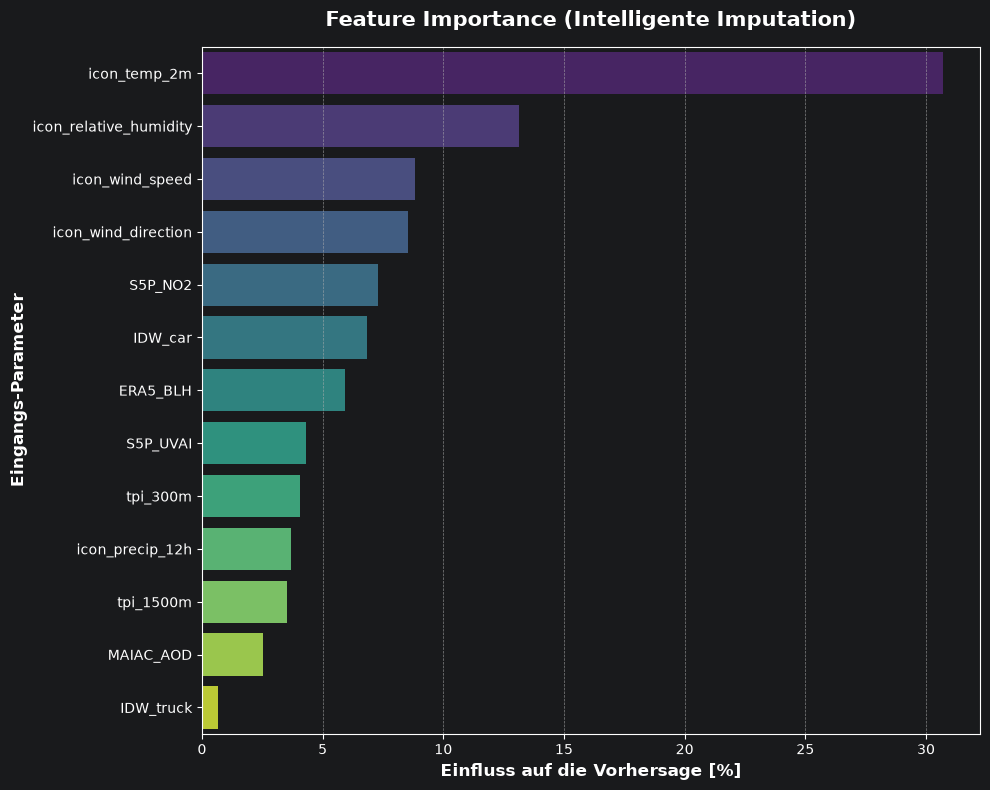

In [11]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
# WICHTIG: enable_iterative_imputer muss VOR dem IterativeImputer importiert werden!
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# =========================================================
# 1. Daten laden & bereinigen
# =========================================================
file_path = r"C:\Users\AD\Desktop\Uni Würzburg\EAGLE\InnoLab\new_Output\IDW_hoch2\Exp2_Features_RH_PM25_NDVI_TPI_S5P_ERA5_MAIAC_Verkehr_Wetter.csv"
df = pd.read_csv(file_path, sep=";", decimal=",")

df['station_id'] = df['station_id'].astype(str).str.strip()

# Kaputte Sensoren entfernen
bad_sensors = ['5456', '15449', '46505', '9094']
df = df[~df['station_id'].isin(bad_sensors)].copy()

# Nur Zeilen behalten, bei denen zumindest das Target (Feinstaub) gemessen wurde
df = df.dropna(subset=['PM25_Target'])

# Datum konvertieren für zeitliche Sortierung
df['date_dt'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)

# =========================================================
# 2. Die INTELLIGENTE Imputation (Zeitlich + Multivariat)
# =========================================================
print("Schritt 1: Führe intelligente Daten-Imputation durch...")

features = [
    #'prox_kumulativ_car', 'prox_kumulativ_truck',
    'IDW_car', 'IDW_truck',
    'icon_temp_2m', 'icon_wind_speed', 'icon_wind_direction',
    'icon_precip_12h', 'icon_relative_humidity',
    'MAIAC_AOD', 'S5P_NO2', 'S5P_UVAI', 'ERA5_BLH',
    'tpi_300m', 'tpi_1500m'
]

# A) Zeitliche Interpolation (Füllt kurze 1-2 Tages-Lücken pro Station)
df = df.sort_values(by=['station_id', 'date_dt'])
df[features] = df.groupby('station_id')[features].transform(
    lambda x: x.interpolate(method='linear', limit=2, limit_direction='both')
)

# B) Multivariate Imputation (MICE) für den Rest
# Nutzt die Zusammenhänge (z.B. Temperatur & NO2) um fehlenden AOD-Wert zu raten
print(" -> Trainiere MICE-Imputer für verbleibende Satelliten-Lücken...")
mice_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42),
    max_iter=10,
    random_state=42
)
df[features] = mice_imputer.fit_transform(df[features])

# Qualitäts-Filter: Sensoren mit ausreichend Tagen behalten
sensor_counts = df['station_id'].value_counts()
df = df[df['station_id'].isin(sensor_counts[sensor_counts >= 20].index)].copy()

# =========================================================
# 3. Hardware-Kalibrierung: Low-Cost an Kopfklinik anpassen
# =========================================================
print("\nSchritt 2: Führe Baseline-Kalibrierung der Hardware durch...")
mean_kopfklinik = df[df['station_id'] == "1"]['PM25_Target'].mean()
mean_lowcost = df[df['station_id'] != "1"]['PM25_Target'].mean()

offset = mean_kopfklinik - mean_lowcost
df.loc[df['station_id'] != "1", 'PM25_Target'] += offset
print(f"-> Systematischer Offset ({offset:.2f} µg/m³) angeglichen!")

# =========================================================
# 4. Leave-Location-Out (LLO) Validierung
# =========================================================
print("\nSchritt 3: Starte optimierte LLO-Kreuzvalidierung...")
print(len(df))

ANCHOR_ID = "1"
test_stations = [s for s in df['station_id'].unique() if s != ANCHOR_ID]

fold_results = []
feature_importances_list = []

rf = RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=4, random_state=42, n_jobs=-1)

for fold, test_sensor in enumerate(test_stations, 1):
    test_mask = df['station_id'] == test_sensor
    df_test = df[test_mask]
    df_train = df[~test_mask]

    if len(df_test) == 0: continue

    # Gewichtung auf 1.0, da Offset bereits korrigiert wurde
    sample_weights = np.where(df_train['station_id'] == ANCHOR_ID, 1.0, 1.0)

    rf.fit(df_train[features], df_train['PM25_Target'], sample_weight=sample_weights)
    y_pred = rf.predict(df_test[features])

    rmse = np.sqrt(mean_squared_error(df_test['PM25_Target'], y_pred))
    r2 = r2_score(df_test['PM25_Target'], y_pred)
    bias = np.mean(y_pred - df_test['PM25_Target'])

    fold_results.append({'Sensor': test_sensor, 'R2': r2, 'RMSE': rmse, 'Bias': bias})
    feature_importances_list.append(rf.feature_importances_)

    print(f"Fold {fold} (Test auf Sensor {test_sensor}): R² = {r2:5.2f} | RMSE = {rmse:4.2f} µg/m³ | Bias = {bias:5.2f} µg/m³")

# =========================================================
# 5. Endauswertung & Feature Importance Plot
# =========================================================
print("\n" + "="*50)
print("GESAMTERGEBNIS DES MICE-IMPUTIERTEN LLO-TESTS:")
print("="*50)
results_df = pd.DataFrame(fold_results)
print(f"Mittlerer R² Score:   {results_df['R2'].mean():.2f}")
print(f"Mittlerer RMSE:       {results_df['RMSE'].mean():.2f} µg/m³")
print(f"Mittlerer Bias:       {results_df['Bias'].mean():.2f} µg/m³")

if feature_importances_list:
    mean_importances = np.mean(feature_importances_list, axis=0)
    importance_df = pd.DataFrame({'Feature': features, 'Wichtigkeit (%)': mean_importances * 100})
    importance_df = importance_df.sort_values(by='Wichtigkeit (%)', ascending=False)

    # Plot
    output_dir = r"C:\Users\AD\Desktop\Uni Würzburg\EAGLE\InnoLab\new_Output\Diagrams"
    os.makedirs(output_dir, exist_ok=True)
    plot_path = os.path.join(output_dir, "Feature_Importance_RF_MICE_Imputed.png")

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Wichtigkeit (%)', y='Feature', data=importance_df, palette='viridis')
    plt.title('Feature Importance (Intelligente Imputation)', fontsize=15, fontweight='bold', pad=15)
    plt.xlabel('Einfluss auf die Vorhersage [%]', fontsize=12, fontweight='bold')
    plt.ylabel('Eingangs-Parameter', fontsize=12, fontweight='bold')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(plot_path, dpi=300)
    plt.show()